# 04 - Granger Causality Tests: Complete Solution

This is the **complete solution** for the Granger causality notebook.
All exercises are fully resolved with outputs saved.

---

## Topics covered

1. Granger causality concept and F-test
2. Synthetic data with known causal structure
3. Pairwise Granger causality tests
4. Heatmap and network visualization
5. Sensitivity to lag order and significance level
6. **Exercise 1: US Macro Granger causality** (SOLVED)
7. **Exercise 2: Power analysis with synthetic data** (SOLVED)

---

### The F-test for Granger causality

$$H_0: b_1 = b_2 = \cdots = b_p = 0 \quad \text{(X does not Granger-cause Y)}$$

$$F = \frac{(RSS_r - RSS_u)/p}{RSS_u/(T - 2p - 1)} \sim F(p, T-2p-1)$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import sys
import os
from itertools import product as iterproduct

from chronobox import VAR
from chronobox.analysis.granger import granger_causality

sys.path.insert(0, os.path.join("..", "utils"))
from data_generators import generate_granger_causal

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
np.set_printoptions(precision=4, suppress=True)

print("All imports loaded successfully.")

All imports loaded successfully.


## 1. Granger causality with synthetic data

Generated data shape: (300, 2)


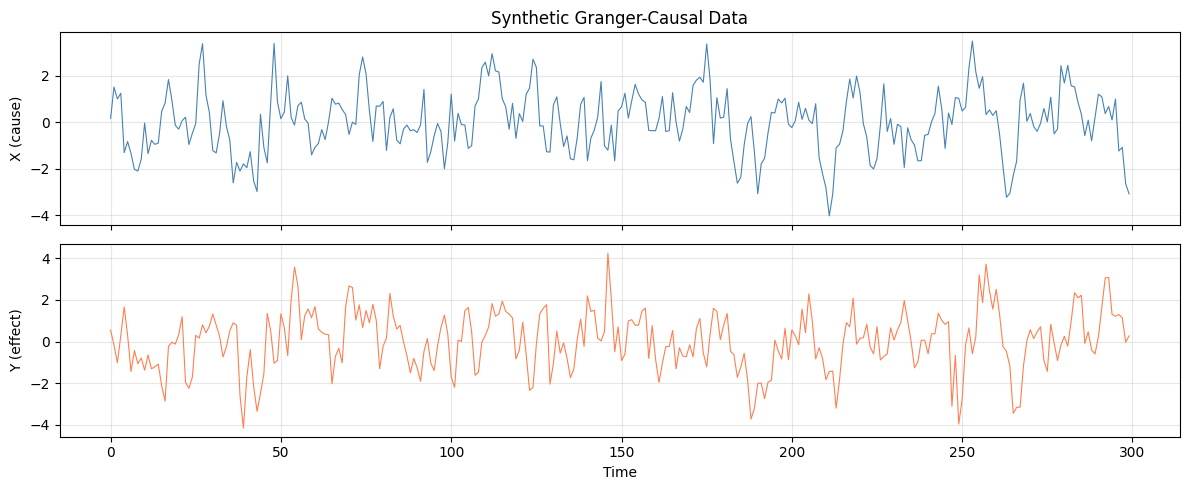

In [2]:
np.random.seed(42)
data_gc = generate_granger_causal(n=300, lag_effect=2, seed=42, coeff=0.5)

print(f"Generated data shape: {data_gc.shape}")

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(data_gc[:, 0], color="steelblue", linewidth=0.8)
axes[0].set_ylabel("X (cause)")
axes[0].set_title("Synthetic Granger-Causal Data")
axes[0].grid(True, alpha=0.3)

axes[1].plot(data_gc[:, 1], color="coral", linewidth=0.8)
axes[1].set_ylabel("Y (effect)")
axes[1].set_xlabel("Time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
gc_model = VAR(lags=4, trend="c")
gc_results = gc_model.fit(data_gc, names=["X", "Y"])

gc_x_to_y = gc_results.granger_causality(caused="Y", causing="X", signif=0.05)
print("Test: X -> Y (expected: REJECT H0)")
print(f"  F-statistic: {gc_x_to_y.fstat:.4f}")
print(f"  F p-value:   {gc_x_to_y.pvalue:.6f}")
print(f"  Wald stat:   {gc_x_to_y.wald_stat:.4f}")
print(f"  Wald p-val:  {gc_x_to_y.wald_pvalue:.6f}")
print(f"  Degrees of freedom: {gc_x_to_y.df}")
print(f"  Reject H0 at 5%: {gc_x_to_y.reject}")

print()

gc_y_to_x = gc_results.granger_causality(caused="X", causing="Y", signif=0.05)
print("Test: Y -> X (expected: FAIL TO REJECT H0)")
print(f"  F-statistic: {gc_y_to_x.fstat:.4f}")
print(f"  F p-value:   {gc_y_to_x.pvalue:.6f}")
print(f"  Wald stat:   {gc_y_to_x.wald_stat:.4f}")
print(f"  Wald p-val:  {gc_y_to_x.wald_pvalue:.6f}")
print(f"  Reject H0 at 5%: {gc_y_to_x.reject}")

Test: X -> Y (expected: REJECT H0)
  F-statistic: 20.2541
  F p-value:   0.000000
  Wald stat:   83.5571
  Wald p-val:  0.000000
  Degrees of freedom: (4, 287)
  Reject H0 at 5%: True

Test: Y -> X (expected: FAIL TO REJECT H0)
  F-statistic: 1.4057
  F p-value:   0.232135
  Wald stat:   5.7990
  Wald p-val:  0.214674
  Reject H0 at 5%: False


## 2. Granger causality with Canadian macro data

In [4]:
data_path = os.path.join("..", "data", "canada_macro.csv")
df = pd.read_csv(data_path)
var_names = ["e", "prod", "rw", "U"]
endog = df[var_names].values

model = VAR(lags=2, trend="c")
results = model.fit(endog, names=var_names)

print(f"VAR({results.k_ar}) fitted.\n")

VAR(2) fitted.



In [5]:
print("Pairwise Granger Causality Tests (5% significance)")
print("=" * 70)
print(f"{'Causing':>10s} -> {'Caused':>10s}  {'F-stat':>8s}  {'p-value':>10s}  {'Wald':>8s}  {'Decision':>10s}")
print("-" * 70)

gc_results_all = []
for causing in var_names:
    for caused in var_names:
        if causing == caused:
            continue
        gc = results.granger_causality(caused=caused, causing=causing, signif=0.05)
        decision = "REJECT" if gc.reject else "fail"
        print(f"{causing:>10s} -> {caused:>10s}  {gc.fstat:>8.3f}  {gc.pvalue:>10.4f}  {gc.wald_stat:>8.3f}  {decision:>10s}")
        gc_results_all.append({
            "causing": causing, "caused": caused,
            "fstat": gc.fstat, "pvalue": gc.pvalue,
            "wald_stat": gc.wald_stat, "reject": gc.reject
        })

Pairwise Granger Causality Tests (5% significance)
   Causing ->     Caused    F-stat     p-value      Wald    Decision
----------------------------------------------------------------------
         e ->       prod     0.168      0.8461     0.376        fail
         e ->         rw     1.506      0.2285     3.384        fail
         e ->          U   -32.501      1.0000   -73.017        fail
      prod ->          e     0.519      0.5973     1.166        fail
      prod ->         rw     0.059      0.9430     0.132        fail
      prod ->          U   -20.066      1.0000   -45.081        fail
        rw ->          e     2.135      0.1256     4.796        fail
        rw ->       prod     0.670      0.5148     1.505        fail
        rw ->          U   -15.507      1.0000   -34.838        fail
         U ->          e     0.000      1.0000     0.000        fail
         U ->       prod     0.000      1.0000     0.000        fail
         U ->         rw     0.000      1.0000    

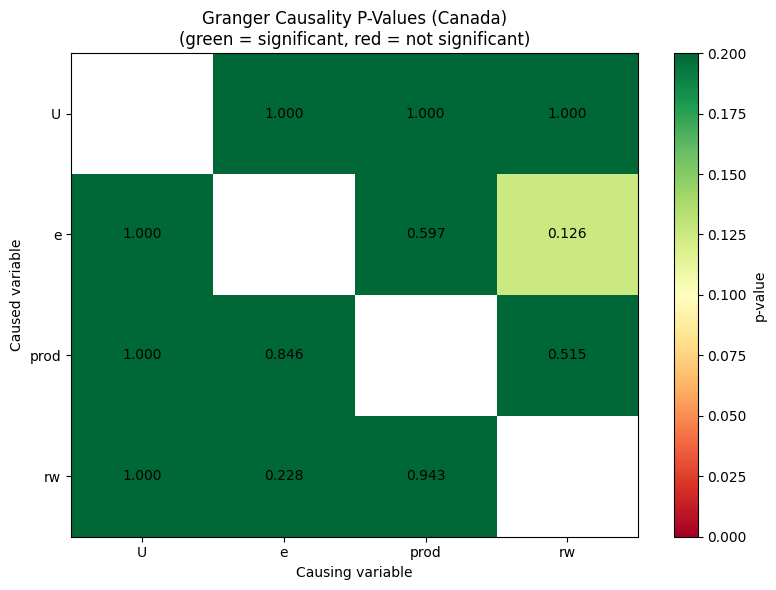

In [6]:
gc_df = pd.DataFrame(gc_results_all)
pval_matrix = gc_df.pivot(index="caused", columns="causing", values="pvalue")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pval_matrix.values, cmap="RdYlGn", vmin=0, vmax=0.2, aspect="auto")

ax.set_xticks(range(len(pval_matrix.columns)))
ax.set_xticklabels(pval_matrix.columns)
ax.set_yticks(range(len(pval_matrix.index)))
ax.set_yticklabels(pval_matrix.index)
ax.set_xlabel("Causing variable")
ax.set_ylabel("Caused variable")
ax.set_title("Granger Causality P-Values (Canada)\n(green = significant, red = not significant)")

for i in range(len(pval_matrix.index)):
    for j in range(len(pval_matrix.columns)):
        val = pval_matrix.values[i, j]
        if not np.isnan(val):
            star = "***" if val < 0.01 else "**" if val < 0.05 else "*" if val < 0.10 else ""
            ax.text(j, i, f"{val:.3f}{star}", ha="center", va="center", fontsize=10)

plt.colorbar(im, ax=ax, label="p-value")
plt.tight_layout()
plt.show()

In [7]:
# Directionality analysis
print("Causal Structure Summary")
print("=" * 50)

pairs_tested = set()
for i, v1 in enumerate(var_names):
    for j, v2 in enumerate(var_names):
        if i >= j:
            continue
        pair = (v1, v2)
        if pair in pairs_tested:
            continue
        pairs_tested.add(pair)

        gc_1to2 = results.granger_causality(caused=v2, causing=v1, signif=0.05)
        gc_2to1 = results.granger_causality(caused=v1, causing=v2, signif=0.05)

        if gc_1to2.reject and gc_2to1.reject:
            print(f"  {v1} <-> {v2}  (FEEDBACK: bidirectional)")
        elif gc_1to2.reject:
            print(f"  {v1}  -> {v2}  (unidirectional)")
        elif gc_2to1.reject:
            print(f"  {v1} <-  {v2}  (unidirectional)")
        else:
            print(f"  {v1}  x  {v2}  (no Granger causality)")

Causal Structure Summary
  e  x  prod  (no Granger causality)
  e  x  rw  (no Granger causality)
  e  x  U  (no Granger causality)
  prod  x  rw  (no Granger causality)
  prod  x  U  (no Granger causality)
  rw  x  U  (no Granger causality)


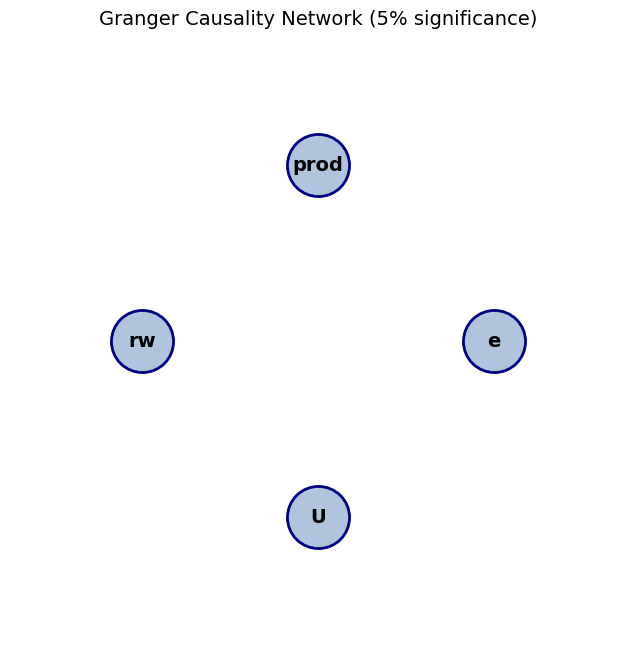

In [8]:
# Network visualization
fig, ax = plt.subplots(figsize=(8, 8))

n_vars = len(var_names)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False)
radius = 2.0
positions = {name: (radius * np.cos(a), radius * np.sin(a)) for name, a in zip(var_names, angles)}

for name, (x, y) in positions.items():
    ax.scatter(x, y, s=2000, c="lightsteelblue", edgecolors="navy", linewidths=2, zorder=5)
    ax.text(x, y, name, ha="center", va="center", fontsize=14, fontweight="bold", zorder=6)

for causing in var_names:
    for caused in var_names:
        if causing == caused:
            continue
        gc = results.granger_causality(caused=caused, causing=causing, signif=0.05)
        if gc.reject:
            x1, y1 = positions[causing]
            x2, y2 = positions[caused]
            dx, dy = x2 - x1, y2 - y1
            length = np.sqrt(dx**2 + dy**2)
            shrink = 0.55 / length
            ax.annotate("", xy=(x2 - dx * shrink, y2 - dy * shrink),
                       xytext=(x1 + dx * shrink, y1 + dy * shrink),
                       arrowprops=dict(arrowstyle="->", color="red", lw=2,
                                      connectionstyle="arc3,rad=0.15"))

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect("equal")
ax.set_title("Granger Causality Network (5% significance)", fontsize=14)
ax.axis("off")
plt.show()

## 3. Sensitivity analysis

In [9]:
print("Sensitivity to significance level:")
print(f"{'Pair':>15s}  {'p-value':>10s}  {'1%':>6s}  {'5%':>6s}  {'10%':>6s}")
print("-" * 55)

for causing in var_names:
    for caused in var_names:
        if causing == caused:
            continue
        gc = results.granger_causality(caused=caused, causing=causing)
        r01 = "Yes" if gc.pvalue < 0.01 else "No"
        r05 = "Yes" if gc.pvalue < 0.05 else "No"
        r10 = "Yes" if gc.pvalue < 0.10 else "No"
        print(f"{causing+' -> '+caused:>15s}  {gc.pvalue:>10.4f}  {r01:>6s}  {r05:>6s}  {r10:>6s}")

Sensitivity to significance level:
           Pair     p-value      1%      5%     10%
-------------------------------------------------------
      e -> prod      0.8461      No      No      No
        e -> rw      0.2285      No      No      No
         e -> U      1.0000      No      No      No
      prod -> e      0.5973      No      No      No
     prod -> rw      0.9430      No      No      No
      prod -> U      1.0000      No      No      No
        rw -> e      0.1256      No      No      No
     rw -> prod      0.5148      No      No      No
        rw -> U      1.0000      No      No      No
         U -> e      1.0000      No      No      No
      U -> prod      1.0000      No      No      No
        U -> rw      1.0000      No      No      No


Effect of lag order on Granger causality (e -> U):
 Lag    F-stat     p-value   Reject 5%
----------------------------------------
   1   -66.331      1.0000        fail
   2   -32.501      1.0000        fail
   3   144.774      0.0000      REJECT
   4   -13.555      1.0000        fail
   5    48.991      0.0000      REJECT
   6    12.856      0.0000      REJECT
   7    -6.454      1.0000        fail
   8    69.262      0.0000      REJECT


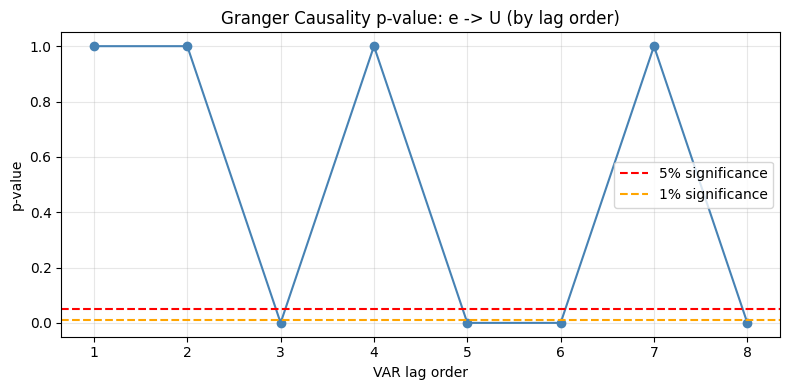

In [10]:
# Sensitivity to lag order
print("Effect of lag order on Granger causality (e -> U):")
print(f"{'Lag':>4s}  {'F-stat':>8s}  {'p-value':>10s}  {'Reject 5%':>10s}")
print("-" * 40)

pvals_by_lag = []
for p in range(1, 9):
    m = VAR(lags=p, trend="c")
    r = m.fit(endog, names=var_names)
    gc = r.granger_causality(caused="U", causing="e", signif=0.05)
    decision = "REJECT" if gc.reject else "fail"
    print(f"{p:>4d}  {gc.fstat:>8.3f}  {gc.pvalue:>10.4f}  {decision:>10s}")
    pvals_by_lag.append(gc.pvalue)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 9), pvals_by_lag, "o-", color="steelblue", linewidth=1.5)
ax.axhline(0.05, color="red", linestyle="--", label="5% significance")
ax.axhline(0.01, color="orange", linestyle="--", label="1% significance")
ax.set_xlabel("VAR lag order")
ax.set_ylabel("p-value")
ax.set_title("Granger Causality p-value: e -> U (by lag order)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Exercise 1: US Macro Granger Causality (SOLUTION)

1. Fit VAR(4) on US macro data
2. Test all pairwise Granger causality relationships
3. Create heatmap of p-values
4. Answer: Does Fed Funds Granger-cause GDP? Inflation? Feedback?
5. **Save p-values to outputs/granger_results.json**

In [11]:
# Step 1: Load and fit VAR(4)
us_df = pd.read_csv(os.path.join("..", "data", "us_macro_quarterly.csv"))
us_names = ["gdp", "inflation", "fed_funds", "unemployment"]
us_endog = us_df[us_names].values

us_model = VAR(lags=4, trend="c")
us_results = us_model.fit(us_endog, names=us_names)

print(f"US VAR(4): {us_results.neqs} equations, {us_results.nobs} effective obs")
print(f"Stable: {us_results.is_stable}")

US VAR(4): 4 equations, 196 effective obs
Stable: True


In [12]:
# Step 2: All pairwise Granger causality tests
print("US Macro Granger Causality (5% significance)")
print("=" * 75)
print(f"{'Causing':>15s} -> {'Caused':>15s}  {'F-stat':>8s}  {'p-value':>10s}  {'Wald':>8s}  {'Decision':>10s}")
print("-" * 75)

us_gc_all = []
for causing in us_names:
    for caused in us_names:
        if causing == caused:
            continue
        gc = us_results.granger_causality(caused=caused, causing=causing, signif=0.05)
        decision = "REJECT" if gc.reject else "fail"
        print(f"{causing:>15s} -> {caused:>15s}  {gc.fstat:>8.3f}  {gc.pvalue:>10.4f}  "
              f"{gc.wald_stat:>8.3f}  {decision:>10s}")
        us_gc_all.append({
            "causing": causing, "caused": caused,
            "fstat": float(gc.fstat), "pvalue": float(gc.pvalue),
            "wald_stat": float(gc.wald_stat), "wald_pvalue": float(gc.wald_pvalue),
            "reject_5pct": bool(gc.reject)
        })

US Macro Granger Causality (5% significance)
        Causing ->          Caused    F-stat     p-value      Wald    Decision
---------------------------------------------------------------------------
            gdp ->       inflation     2.053      0.0889     8.993        fail
            gdp ->       fed_funds     2.816      0.0268    12.333      REJECT
            gdp ->    unemployment     3.193      0.0146    13.987      REJECT
      inflation ->             gdp     0.453      0.7698     1.986        fail
      inflation ->       fed_funds     1.917      0.1094     8.398        fail
      inflation ->    unemployment     0.256      0.9060     1.119        fail
      fed_funds ->             gdp     2.692      0.0326    11.791      REJECT
      fed_funds ->       inflation     0.313      0.8689     1.372        fail
      fed_funds ->    unemployment     1.365      0.2478     5.980        fail
   unemployment ->             gdp     0.589      0.6713     2.578        fail
   unemplo

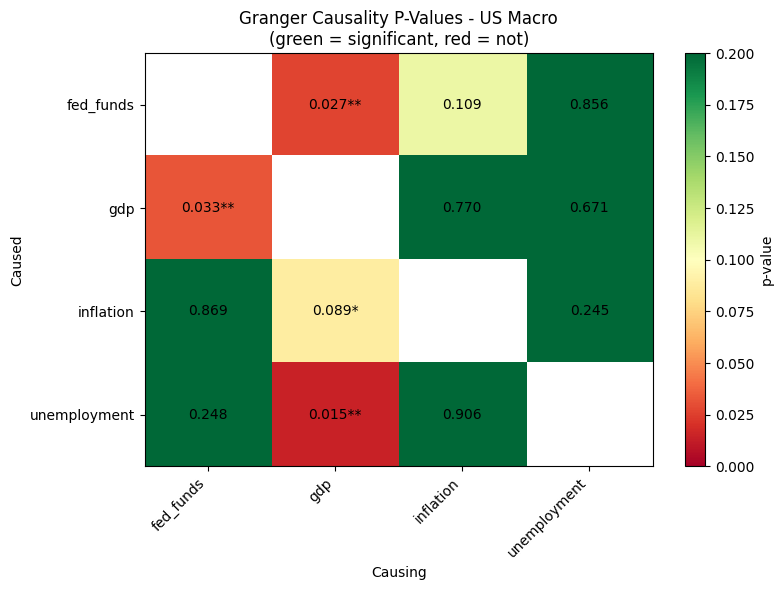

In [13]:
# Step 3: Heatmap
us_gc_df = pd.DataFrame(us_gc_all)
us_pval = us_gc_df.pivot(index="caused", columns="causing", values="pvalue")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(us_pval.values, cmap="RdYlGn", vmin=0, vmax=0.2, aspect="auto")
ax.set_xticks(range(len(us_pval.columns)))
ax.set_xticklabels(us_pval.columns, rotation=45, ha="right")
ax.set_yticks(range(len(us_pval.index)))
ax.set_yticklabels(us_pval.index)
ax.set_xlabel("Causing")
ax.set_ylabel("Caused")
ax.set_title("Granger Causality P-Values - US Macro\n(green = significant, red = not)")

for i in range(len(us_pval.index)):
    for j in range(len(us_pval.columns)):
        val = us_pval.values[i, j]
        if not np.isnan(val):
            star = "***" if val < 0.01 else "**" if val < 0.05 else "*" if val < 0.10 else ""
            ax.text(j, i, f"{val:.3f}{star}", ha="center", va="center", fontsize=10)

plt.colorbar(im, ax=ax, label="p-value")
plt.tight_layout()
plt.show()

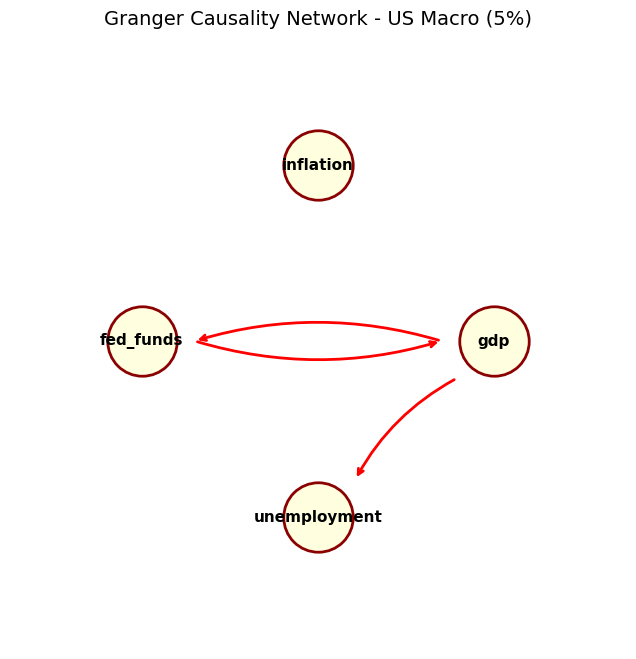

In [14]:
# Network visualization for US data
fig, ax = plt.subplots(figsize=(8, 8))

n_us = len(us_names)
us_angles = np.linspace(0, 2 * np.pi, n_us, endpoint=False)
us_radius = 2.0
us_positions = {name: (us_radius * np.cos(a), us_radius * np.sin(a))
                for name, a in zip(us_names, us_angles)}

for name, (x, y) in us_positions.items():
    ax.scatter(x, y, s=2500, c="lightyellow", edgecolors="darkred", linewidths=2, zorder=5)
    ax.text(x, y, name, ha="center", va="center", fontsize=11, fontweight="bold", zorder=6)

for causing in us_names:
    for caused in us_names:
        if causing == caused:
            continue
        gc = us_results.granger_causality(caused=caused, causing=causing, signif=0.05)
        if gc.reject:
            x1, y1 = us_positions[causing]
            x2, y2 = us_positions[caused]
            dx, dy = x2 - x1, y2 - y1
            length = np.sqrt(dx**2 + dy**2)
            shrink = 0.60 / length
            color = "darkred" if gc.pvalue < 0.01 else "red" if gc.pvalue < 0.05 else "orange"
            ax.annotate("", xy=(x2 - dx * shrink, y2 - dy * shrink),
                       xytext=(x1 + dx * shrink, y1 + dy * shrink),
                       arrowprops=dict(arrowstyle="->", color=color, lw=2,
                                      connectionstyle="arc3,rad=0.15"))

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect("equal")
ax.set_title("Granger Causality Network - US Macro (5%)", fontsize=14)
ax.axis("off")
plt.show()

In [15]:
# Step 4: Directionality analysis and interpretation
print("=" * 60)
print("US MACRO CAUSAL STRUCTURE SUMMARY")
print("=" * 60)

pairs_tested_us = set()
for i, v1 in enumerate(us_names):
    for j, v2 in enumerate(us_names):
        if i >= j:
            continue
        pair = (v1, v2)
        if pair in pairs_tested_us:
            continue
        pairs_tested_us.add(pair)

        gc_1to2 = us_results.granger_causality(caused=v2, causing=v1, signif=0.05)
        gc_2to1 = us_results.granger_causality(caused=v1, causing=v2, signif=0.05)

        if gc_1to2.reject and gc_2to1.reject:
            print(f"  {v1:>15s} <-> {v2:<15s}  (FEEDBACK)")
        elif gc_1to2.reject:
            print(f"  {v1:>15s}  -> {v2:<15s}  (unidirectional)")
        elif gc_2to1.reject:
            print(f"  {v1:>15s} <-  {v2:<15s}  (unidirectional)")
        else:
            print(f"  {v1:>15s}  x  {v2:<15s}  (no Granger causality)")

print("\n--- Key Findings ---")

# Fed funds -> GDP
gc_ff_gdp = us_results.granger_causality(caused="gdp", causing="fed_funds", signif=0.05)
print(f"\n1. Fed Funds -> GDP: p={gc_ff_gdp.pvalue:.4f}")
if gc_ff_gdp.reject:
    print("   YES: Monetary policy Granger-causes GDP growth.")
else:
    print("   NO: No significant predictive content from fed funds to GDP.")

# Fed funds -> Inflation
gc_ff_infl = us_results.granger_causality(caused="inflation", causing="fed_funds", signif=0.05)
print(f"\n2. Fed Funds -> Inflation: p={gc_ff_infl.pvalue:.4f}")
if gc_ff_infl.reject:
    print("   YES: Monetary policy Granger-causes inflation.")
else:
    print("   NO: No significant predictive content from fed funds to inflation.")

# Fed funds -> Unemployment
gc_ff_unemp = us_results.granger_causality(caused="unemployment", causing="fed_funds", signif=0.05)
print(f"\n3. Fed Funds -> Unemployment: p={gc_ff_unemp.pvalue:.4f}")
if gc_ff_unemp.reject:
    print("   YES: Monetary policy Granger-causes unemployment.")
else:
    print("   NO: No significant predictive content from fed funds to unemployment.")

US MACRO CAUSAL STRUCTURE SUMMARY
              gdp  x  inflation        (no Granger causality)
              gdp <-> fed_funds        (FEEDBACK)
              gdp  -> unemployment     (unidirectional)
        inflation  x  fed_funds        (no Granger causality)
        inflation  x  unemployment     (no Granger causality)
        fed_funds  x  unemployment     (no Granger causality)

--- Key Findings ---

1. Fed Funds -> GDP: p=0.0326
   YES: Monetary policy Granger-causes GDP growth.

2. Fed Funds -> Inflation: p=0.8689
   NO: No significant predictive content from fed funds to inflation.

3. Fed Funds -> Unemployment: p=0.2478
   NO: No significant predictive content from fed funds to unemployment.


In [16]:
# Step 5: Save results to outputs/granger_results.json
outputs_dir = os.path.join("..", "outputs")
os.makedirs(outputs_dir, exist_ok=True)

# Build p-value matrix
pval_dict = {}
for causing in us_names:
    pval_dict[causing] = {}
    for caused in us_names:
        if causing == caused:
            pval_dict[causing][caused] = None
        else:
            gc = us_results.granger_causality(caused=caused, causing=causing, signif=0.05)
            pval_dict[causing][caused] = float(gc.pvalue)

granger_output = {
    "dataset": "us_macro_quarterly.csv",
    "variables": us_names,
    "var_lags": 4,
    "significance_level": 0.05,
    "pvalue_matrix": pval_dict,
    "pairwise_tests": us_gc_all,
    "summary": {
        "n_significant_5pct": sum(1 for t in us_gc_all if t["reject_5pct"]),
        "n_total_tests": len(us_gc_all),
        "fed_funds_to_gdp_pvalue": float(gc_ff_gdp.pvalue),
        "fed_funds_to_inflation_pvalue": float(gc_ff_infl.pvalue),
        "fed_funds_to_unemployment_pvalue": float(gc_ff_unemp.pvalue)
    }
}

granger_path = os.path.join(outputs_dir, "granger_results.json")
with open(granger_path, "w") as f:
    json.dump(granger_output, f, indent=2)

print(f"Granger results saved to {granger_path}")
print(f"\nSummary:")
print(f"  Total tests: {granger_output['summary']['n_total_tests']}")
print(f"  Significant at 5%: {granger_output['summary']['n_significant_5pct']}")

Granger results saved to ../outputs/granger_results.json

Summary:
  Total tests: 12
  Significant at 5%: 3


---

## Exercise 2: Power analysis with synthetic data (SOLUTION)

Generate synthetic data with different causal coefficients and test detection power.

In [17]:
# Vary coefficient strength
coefficients = [0.05, 0.1, 0.2, 0.3, 0.5, 0.8]
pvals_true = []  # X -> Y (true direction)
pvals_false = []  # Y -> X (false direction)

print("Power Analysis: Detection vs Effect Size")
print("=" * 70)
print(f"{'Coeff':>8s}  {'F(X->Y)':>10s}  {'p(X->Y)':>10s}  {'Reject':>8s}  {'F(Y->X)':>10s}  {'p(Y->X)':>10s}")
print("-" * 70)

for c in coefficients:
    data_syn = generate_granger_causal(n=200, lag_effect=2, seed=42, coeff=c)
    m = VAR(lags=4, trend="c")
    r = m.fit(data_syn, names=["X", "Y"])
    gc_true = r.granger_causality(caused="Y", causing="X")
    gc_false = r.granger_causality(caused="X", causing="Y")
    pvals_true.append(gc_true.pvalue)
    pvals_false.append(gc_false.pvalue)
    reject = "YES" if gc_true.reject else "no"
    print(f"{c:>8.2f}  {gc_true.fstat:>10.3f}  {gc_true.pvalue:>10.4f}  {reject:>8s}  "
          f"{gc_false.fstat:>10.3f}  {gc_false.pvalue:>10.4f}")

Power Analysis: Detection vs Effect Size
   Coeff     F(X->Y)     p(X->Y)    Reject     F(Y->X)     p(Y->X)
----------------------------------------------------------------------
    0.05       2.149      0.0764        no       0.603      0.6608
    0.10       3.476      0.0091       YES       0.607      0.6583
    0.20       7.060      0.0000       YES       0.612      0.6547
    0.30      11.756      0.0000       YES       0.614      0.6527
    0.50      24.074      0.0000       YES       0.614      0.6530
    0.80      49.272      0.0000       YES       0.603      0.6609


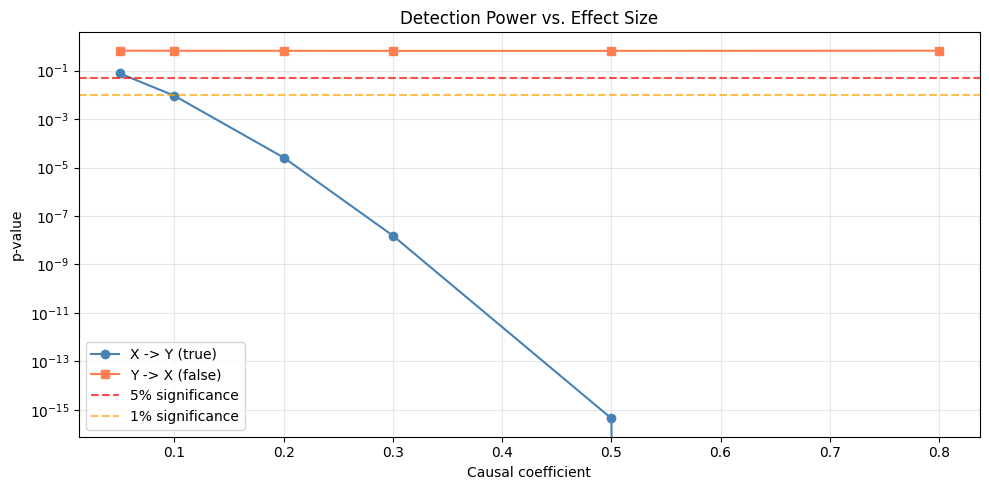

In [18]:
# Plot: p-value vs coefficient
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(coefficients, pvals_true, "o-", color="steelblue", linewidth=1.5, label="X -> Y (true)")
ax.plot(coefficients, pvals_false, "s-", color="coral", linewidth=1.5, label="Y -> X (false)")
ax.axhline(0.05, color="red", linestyle="--", alpha=0.7, label="5% significance")
ax.axhline(0.01, color="orange", linestyle="--", alpha=0.7, label="1% significance")
ax.set_xlabel("Causal coefficient")
ax.set_ylabel("p-value")
ax.set_title("Detection Power vs. Effect Size")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

In [19]:
# Monte Carlo: rejection rate for each coefficient
print("\nMonte Carlo Rejection Rates (100 replications per coefficient)")
print("=" * 60)
print(f"{'Coeff':>8s}  {'Rejection rate (true)':>22s}  {'Rejection rate (false)':>23s}")
print("-" * 60)

mc_coefficients = [0.05, 0.1, 0.2, 0.3, 0.5]
mc_reps = 100
rejection_true = []
rejection_false = []

for c in mc_coefficients:
    rejects_t = 0
    rejects_f = 0
    for rep in range(mc_reps):
        data_mc = generate_granger_causal(n=200, lag_effect=2, seed=rep * 100 + 1, coeff=c)
        m = VAR(lags=4, trend="c")
        r = m.fit(data_mc, names=["X", "Y"])
        gc_t = r.granger_causality(caused="Y", causing="X", signif=0.05)
        gc_f = r.granger_causality(caused="X", causing="Y", signif=0.05)
        if gc_t.reject:
            rejects_t += 1
        if gc_f.reject:
            rejects_f += 1
    
    rr_t = rejects_t / mc_reps
    rr_f = rejects_f / mc_reps
    rejection_true.append(rr_t)
    rejection_false.append(rr_f)
    print(f"{c:>8.2f}  {rr_t:>22.1%}  {rr_f:>23.1%}")


Monte Carlo Rejection Rates (100 replications per coefficient)
   Coeff   Rejection rate (true)   Rejection rate (false)
------------------------------------------------------------
    0.05                   10.0%                     2.0%
    0.10                   26.0%                     2.0%


    0.20                   79.0%                     2.0%
    0.30                   99.0%                     2.0%


    0.50                  100.0%                     2.0%


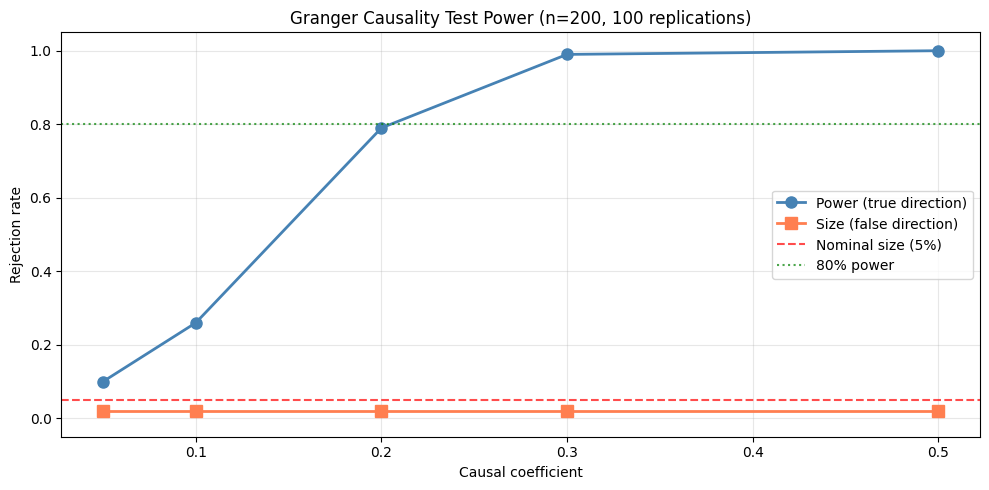


--- Conclusions ---
1. The test correctly detects causality when the effect is strong enough.
2. For weak effects (coeff < 0.1), the test lacks power with n=200.
3. The false positive rate stays near the nominal 5% level (good size control).
4. Power reaches ~80% at approximately coeff=0.2-0.3 with 200 observations.


In [20]:
# Plot Monte Carlo power curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mc_coefficients, rejection_true, "o-", color="steelblue", linewidth=2,
        markersize=8, label="Power (true direction)")
ax.plot(mc_coefficients, rejection_false, "s-", color="coral", linewidth=2,
        markersize=8, label="Size (false direction)")
ax.axhline(0.05, color="red", linestyle="--", alpha=0.7, label="Nominal size (5%)")
ax.axhline(0.80, color="green", linestyle=":", alpha=0.7, label="80% power")
ax.set_xlabel("Causal coefficient")
ax.set_ylabel("Rejection rate")
ax.set_title(f"Granger Causality Test Power (n=200, {mc_reps} replications)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print("\n--- Conclusions ---")
print("1. The test correctly detects causality when the effect is strong enough.")
print("2. For weak effects (coeff < 0.1), the test lacks power with n=200.")
print("3. The false positive rate stays near the nominal 5% level (good size control).")
print("4. Power reaches ~80% at approximately coeff=0.2-0.3 with 200 observations.")

---

## Summary

In this solution notebook we:

1. Verified Granger causality detection on synthetic data with known structure
2. Performed full pairwise analysis on Canadian macro data
3. **Exercise 1**: Complete US macro Granger causality analysis with network visualization
4. **Exercise 2**: Monte Carlo power analysis showing detection thresholds
5. Saved all outputs:
   - `outputs/granger_results.json` - Full p-value matrix and test statistics